In [3]:
import pandas as pd
from pathlib import Path
import glob

# =========================
# 1. 路徑設定
# =========================
air_paths = {
    "汐止": r"C:\臺大雲端\lab\北部空品區_2025\汐止_2025.csv",
    "富貴角": r"C:\臺大雲端\lab\北部空品區_2025\富貴角_2025.csv",
    "基隆": r"C:\臺大雲端\lab\北部空品區_2025\基隆_2025.csv",
}

pinglin_folder = r"C:\臺大雲端\lab\2025坪林風速風向"
pinglin_pattern = str(Path(pinglin_folder) / "C0A530-2025-*-WindSpeed,WindDirection-hour.csv")


# =========================
# 2. 讀取空品資料
# =========================
def read_air_quality_epa(path, station_name):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")

    hour_cols = [f"{h:02d}" for h in range(24)]

    long = df.melt(
        id_vars=["測站", "日期", "測項"],
        value_vars=hour_cols,
        var_name="hour",
        value_name="value"
    )

    long["date"] = pd.to_datetime(long["日期"], errors="coerce")
    long["datetime"] = long["date"] + pd.to_timedelta(long["hour"].astype(int), unit="h")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")

    wide = long.pivot_table(
        index="datetime",
        columns="測項",
        values="value",
        aggfunc="mean"
    ).reset_index()

    wide.columns.name = None
    wide["station"] = station_name

    return wide


air_all = pd.concat(
    [read_air_quality_epa(path, station) for station, path in air_paths.items()],
    ignore_index=True
)

print("空品資料完成")
print(air_all.head())
print(air_all["station"].unique())


# =========================
# 3. 讀取坪林每月風速風向資料
# =========================
def read_pinglin_wind_file(path):
    filename = Path(path).name
    parts = filename.split("-")

    year = int(parts[1])
    month = int(parts[2])

    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")

    hour_cols = [str(h) for h in range(1, 25)]

    long = df.melt(
        id_vars=["日/時"],
        value_vars=hour_cols,
        var_name="hour",
        value_name="wind_raw"
    )

    long["day"] = pd.to_numeric(long["日/時"], errors="coerce")
    long["hour"] = pd.to_numeric(long["hour"], errors="coerce")

    # 先移除 day 或 hour 不是數字的列
    long = long.dropna(subset=["day", "hour"]).copy()

    long["day"] = long["day"].astype(int)
    long["hour"] = long["hour"].astype(int)

    long["datetime"] = (
        pd.to_datetime(
            {
                "year": year,
                "month": month,
                "day": long["day"]
            },
            errors="coerce"
        )
        + pd.to_timedelta(long["hour"] - 1, unit="h")
    )

    wind_split = long["wind_raw"].astype(str).str.split("/", expand=True)

    long["Pinglin_WS"] = pd.to_numeric(
        wind_split[0].str.strip().replace(["--", "nan", ""], pd.NA),
        errors="coerce"
    )

    long["Pinglin_WD"] = pd.to_numeric(
        wind_split[1].str.strip().replace(["--", "nan", ""], pd.NA),
        errors="coerce"
    )

    return long[["datetime", "Pinglin_WS", "Pinglin_WD"]]

def read_pinglin_wind_all(pattern):
    files = sorted(glob.glob(pattern))
    print(f"找到 {len(files)} 個坪林風速風向月資料檔")

    pinglin_all = pd.concat(
        [read_pinglin_wind_file(f) for f in files],
        ignore_index=True
    )

    pinglin_all = (
        pinglin_all
        .dropna(subset=["datetime"])
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    return pinglin_all


pinglin_wind = read_pinglin_wind_all(pinglin_pattern)

print("坪林風速風向資料完成")
print(pinglin_wind.head())
print(pinglin_wind.tail())


# =========================
# 4. 合併空品資料 + 坪林風速風向
# =========================
data = pd.merge(
    air_all,
    pinglin_wind,
    on="datetime",
    how="left"
)

print("合併完成")
print(data.head())
print(data.columns)


# =========================
# 5. 分測站取出資料
# =========================
xizhi = data[data["station"] == "汐止"].copy()
fugui = data[data["station"] == "富貴角"].copy()
keelung = data[data["station"] == "基隆"].copy()

空品資料完成
             datetime  AMB_TEMP    CO   NO   NO2   NOx    O3  PM10  PM2.5  \
0 2025-01-01 00:00:00      15.6  0.42  0.8  14.8  15.7  44.7  71.0   38.0   
1 2025-01-01 01:00:00      15.7  0.40  0.8  15.1  15.9  41.4  55.0   31.0   
2 2025-01-01 02:00:00      15.6  0.37  0.6  16.1  16.7  37.5  56.0   27.0   
3 2025-01-01 03:00:00      15.7  0.28  0.5  14.1  14.6  36.3  53.0   26.0   
4 2025-01-01 04:00:00      16.1  0.26  0.4  12.8  13.2  34.7  48.0   18.0   

   RAINFALL    RH  SO2  WD_HR  WIND_DIREC  WIND_SPEED  WS_HR station  CH4  \
0       0.0  71.0  1.7   41.0        21.0         0.4    0.4      汐止  NaN   
1       0.0  70.0  2.0   23.0        28.0         0.3    0.7      汐止  NaN   
2       0.0  72.0  3.2   31.0        47.0         0.5    0.5      汐止  NaN   
3       0.0  72.0  1.5   25.0        26.0         0.8    0.8      汐止  NaN   
4       0.0  74.0  2.1   26.0        50.0         0.4    0.6      汐止  NaN   

   NMHC  THC  
0   NaN  NaN  
1   NaN  NaN  
2   NaN  NaN  
3   NaN

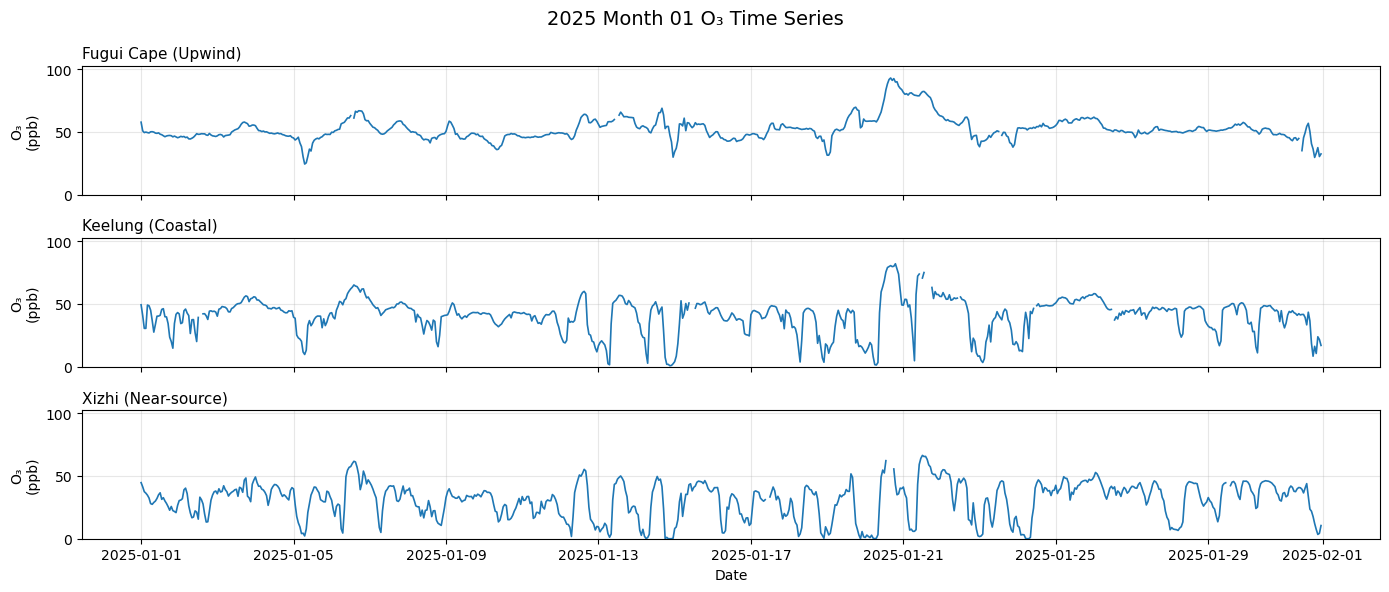

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 測站傳輸順序
# =========================
station_order = [
    "Fugui Cape (Upwind)",
    "Keelung (Coastal)",
    "Xizhi (Near-source)"
]

station_map = {
    "富貴角": "Fugui Cape (Upwind)",
    "基隆": "Keelung (Coastal)",
    "汐止": "Xizhi (Near-source)"
}

# 臭氧欄位名稱，依你的資料可能是 O3 或 O₃
o3_col = "O3"

if o3_col not in data.columns:
    print(data.columns)
    raise ValueError("找不到 O3 欄位，請確認臭氧欄位名稱")


# =========================
# 2. 基本整理
# =========================
plot_df = data.copy()
plot_df["datetime"] = pd.to_datetime(plot_df["datetime"])
plot_df["month"] = plot_df["datetime"].dt.month

plot_df["station_en"] = plot_df["station"].map(station_map)

# =========================
# 3. 畫單一月份 O3 時序圖
# =========================
def plot_monthly_o3(month, save=False):
    df_m = plot_df[plot_df["month"] == month].copy()

    fig, axes = plt.subplots(
        nrows=len(station_order),
        ncols=1,
        figsize=(14, 6),
        sharex=True
    )

    if len(station_order) == 1:
        axes = [axes]

    for ax, station in zip(axes, station_order):
        d = df_m[df_m["station_en"] == station]

        ax.plot(
            d["datetime"],
            d[o3_col],
            linewidth=1.2,
            label=station
        )

        ax.set_ylabel("O₃\n(ppb)")
        ax.set_title(station, loc="left", fontsize=11)
        ax.grid(alpha=0.3)

        ax.set_ylim(0, max(100, df_m[o3_col].max() * 1.1))

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"2025 Month {month:02d} O₃ Time Series", fontsize=14)

    plt.tight_layout()

    if save:
        plt.savefig(f"O3_timeseries_2025_{month:02d}.png", dpi=300, bbox_inches="tight")

    plt.show()


# =========================
# 4. 先畫 1 月
# =========================
plot_monthly_o3(1, save=False)

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_01.png


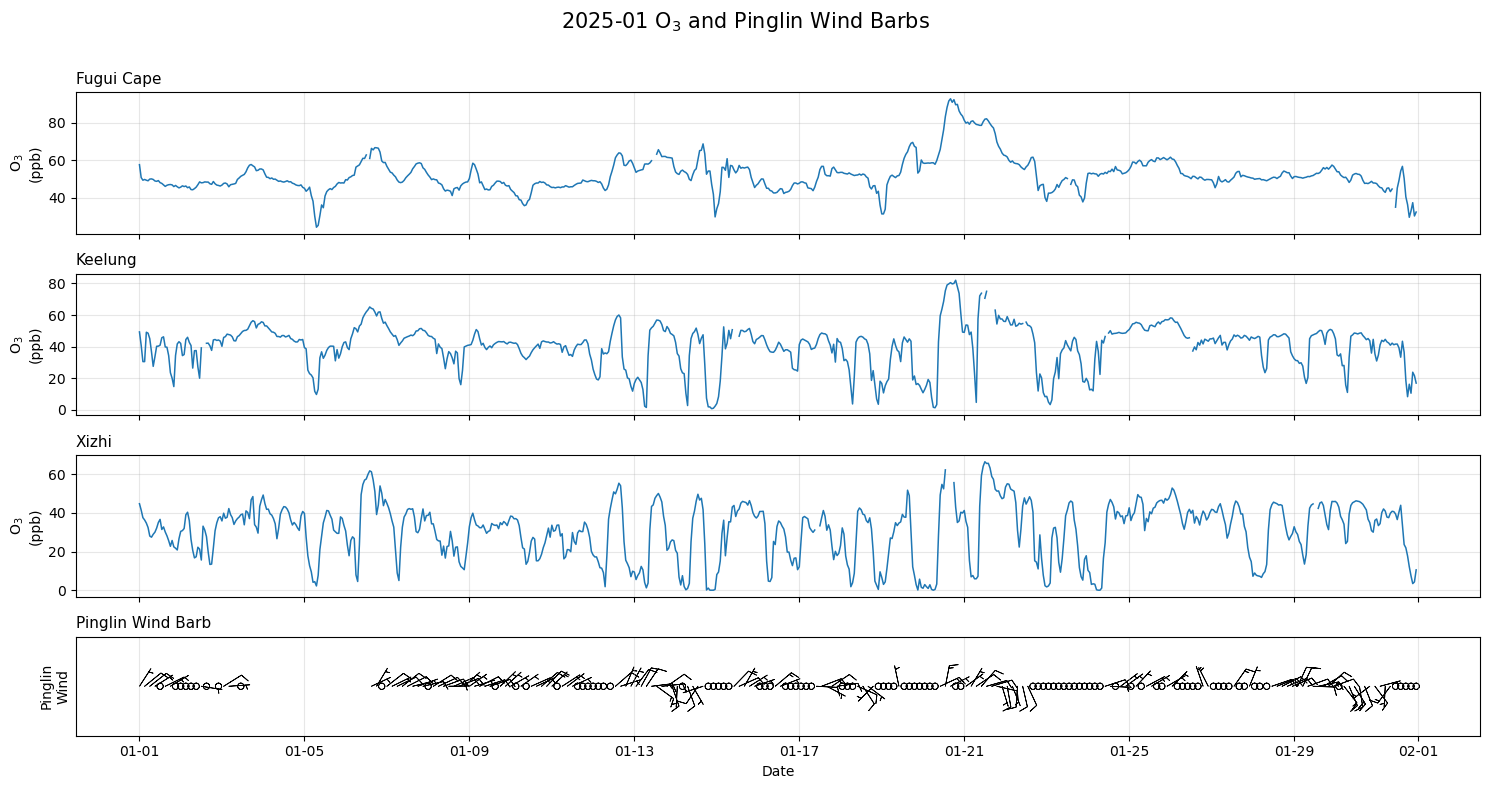

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_02.png


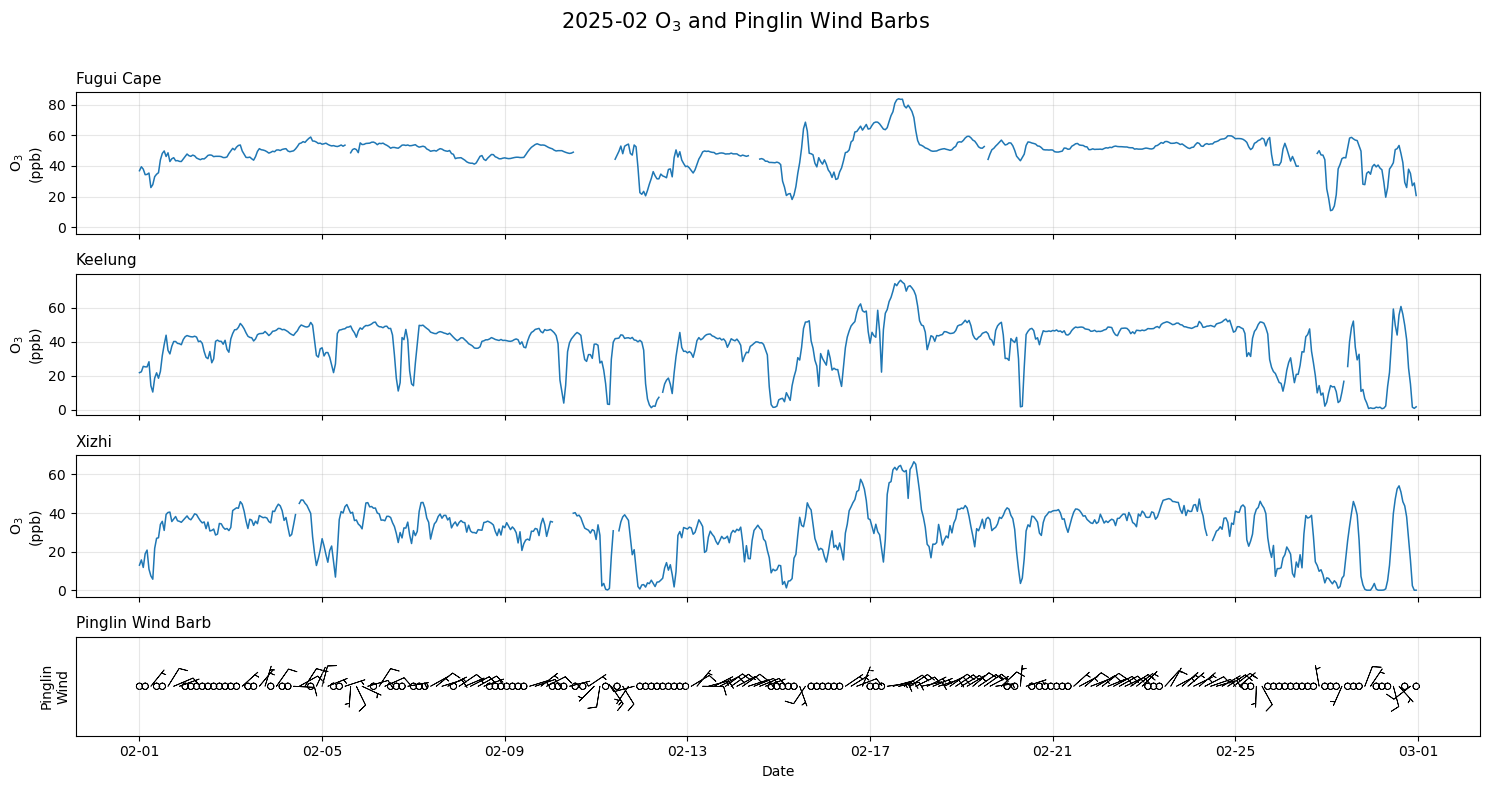

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_03.png


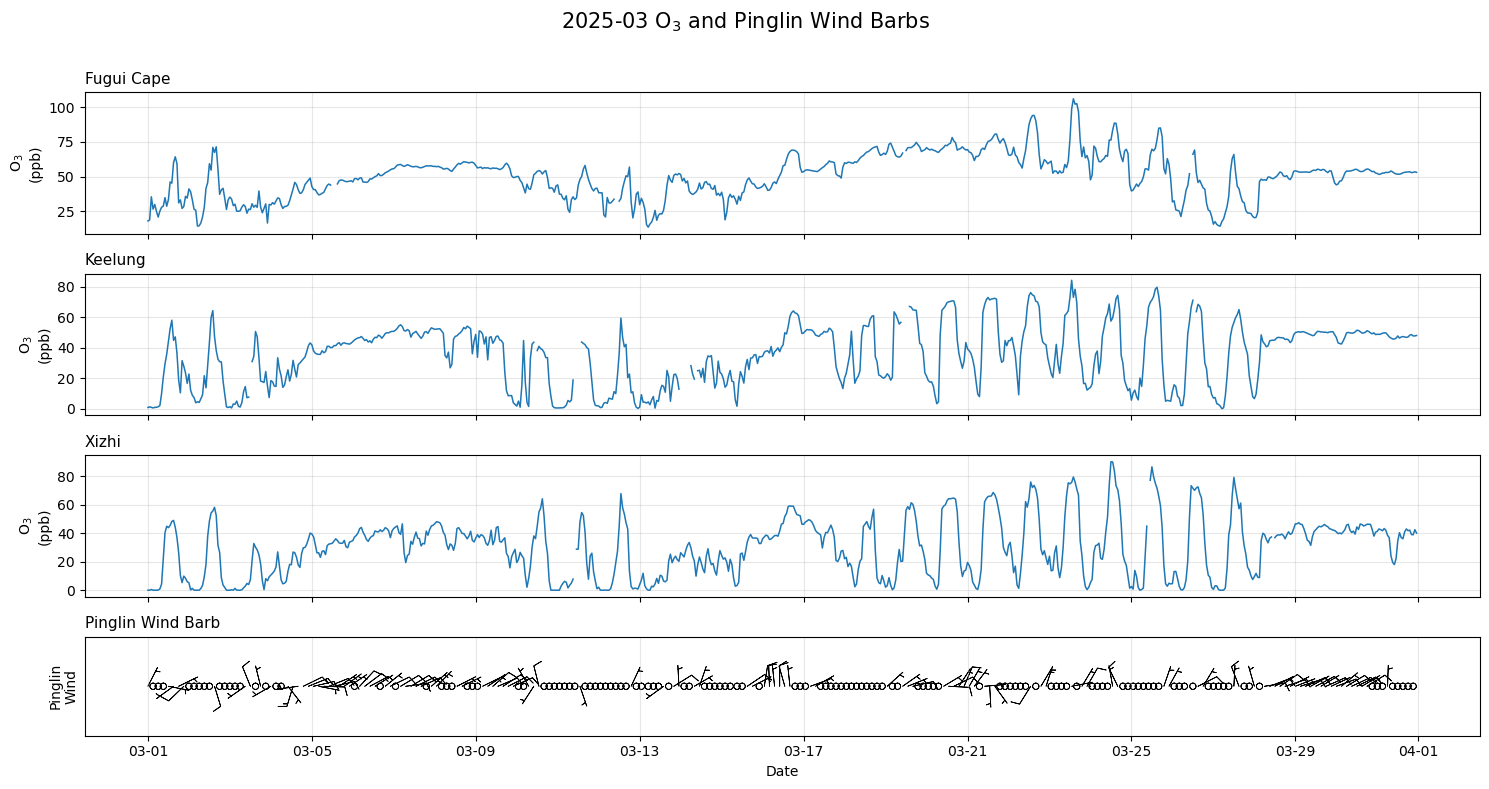

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_04.png


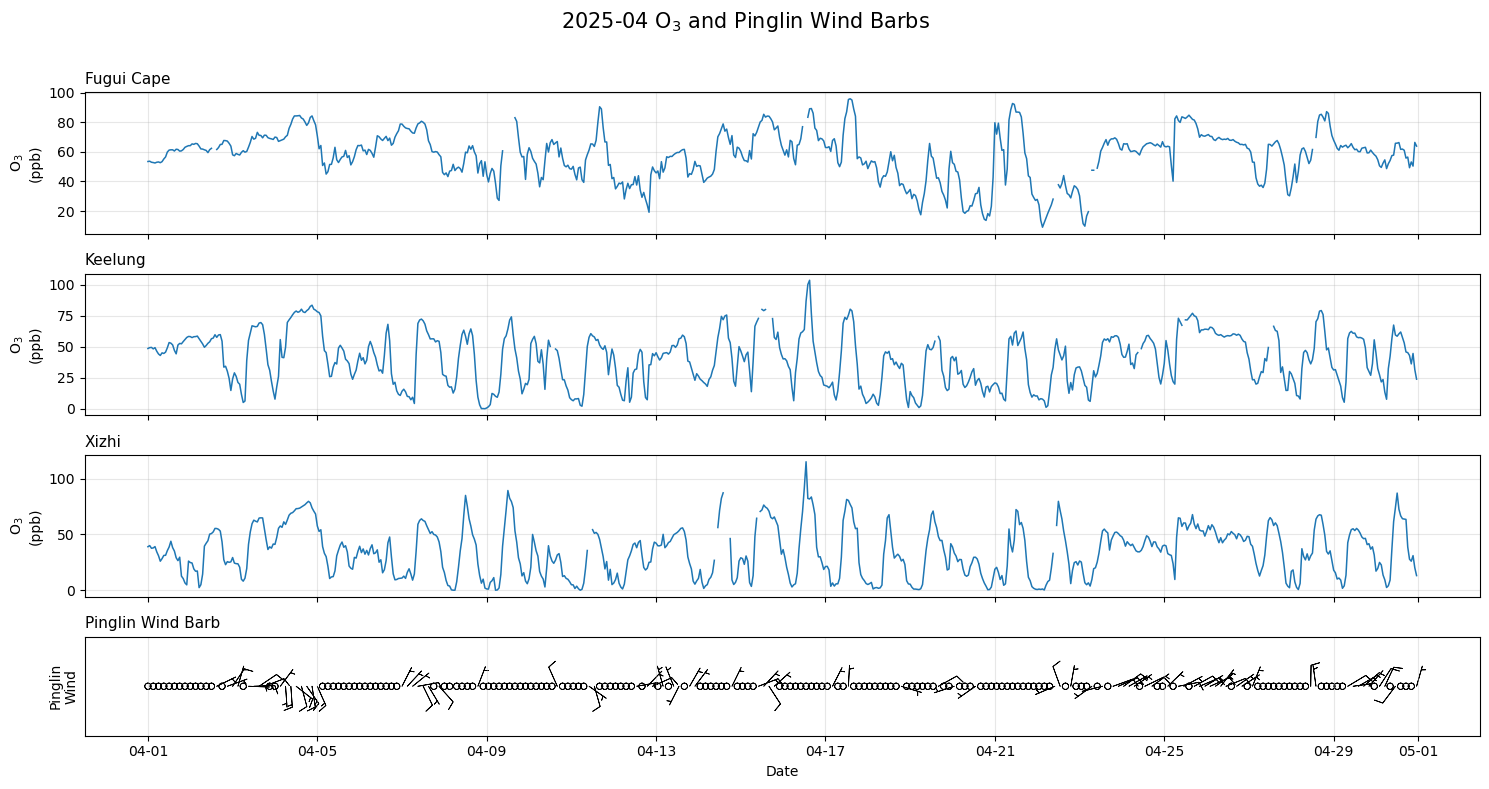

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_05.png


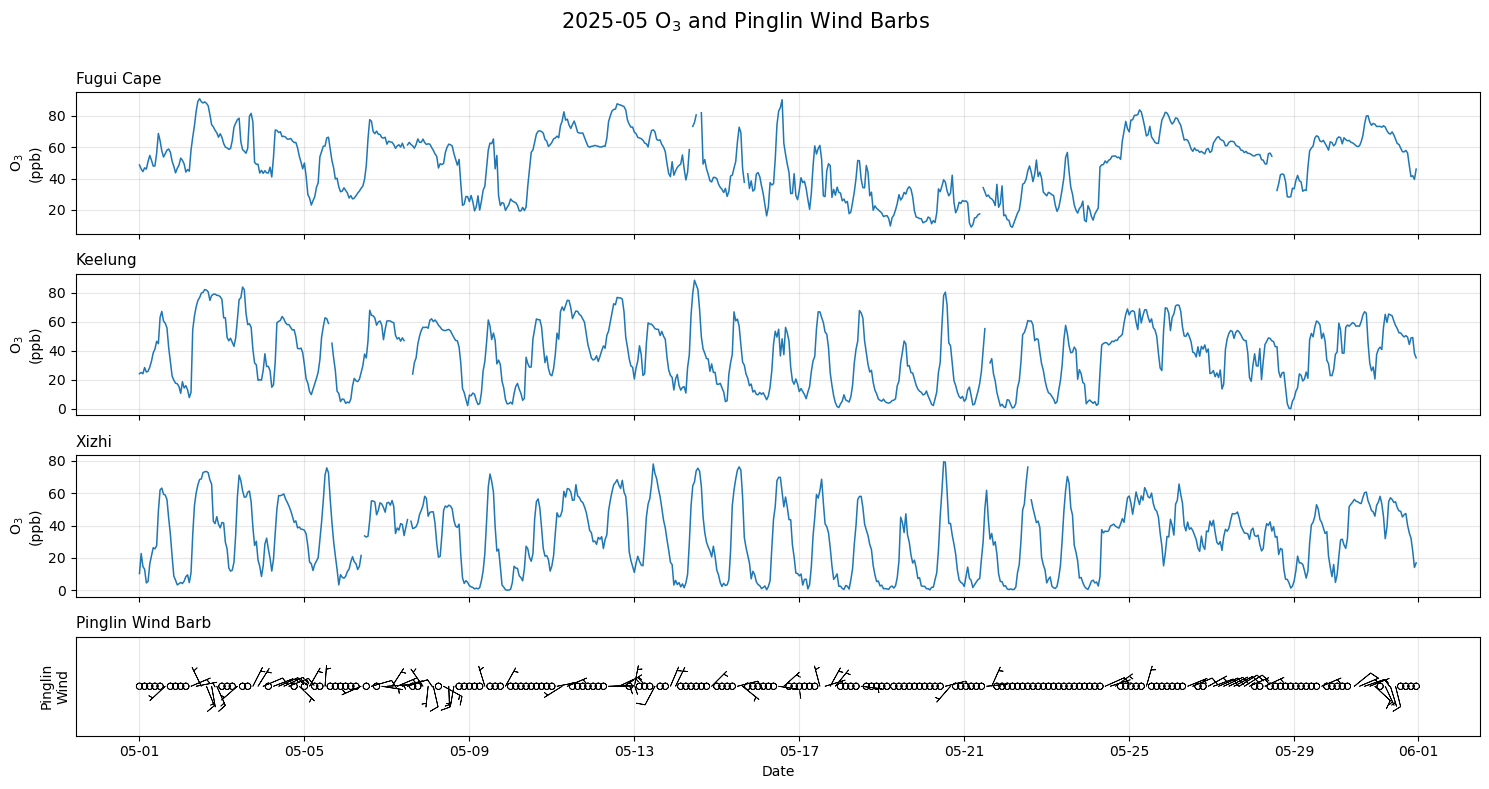

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_06.png


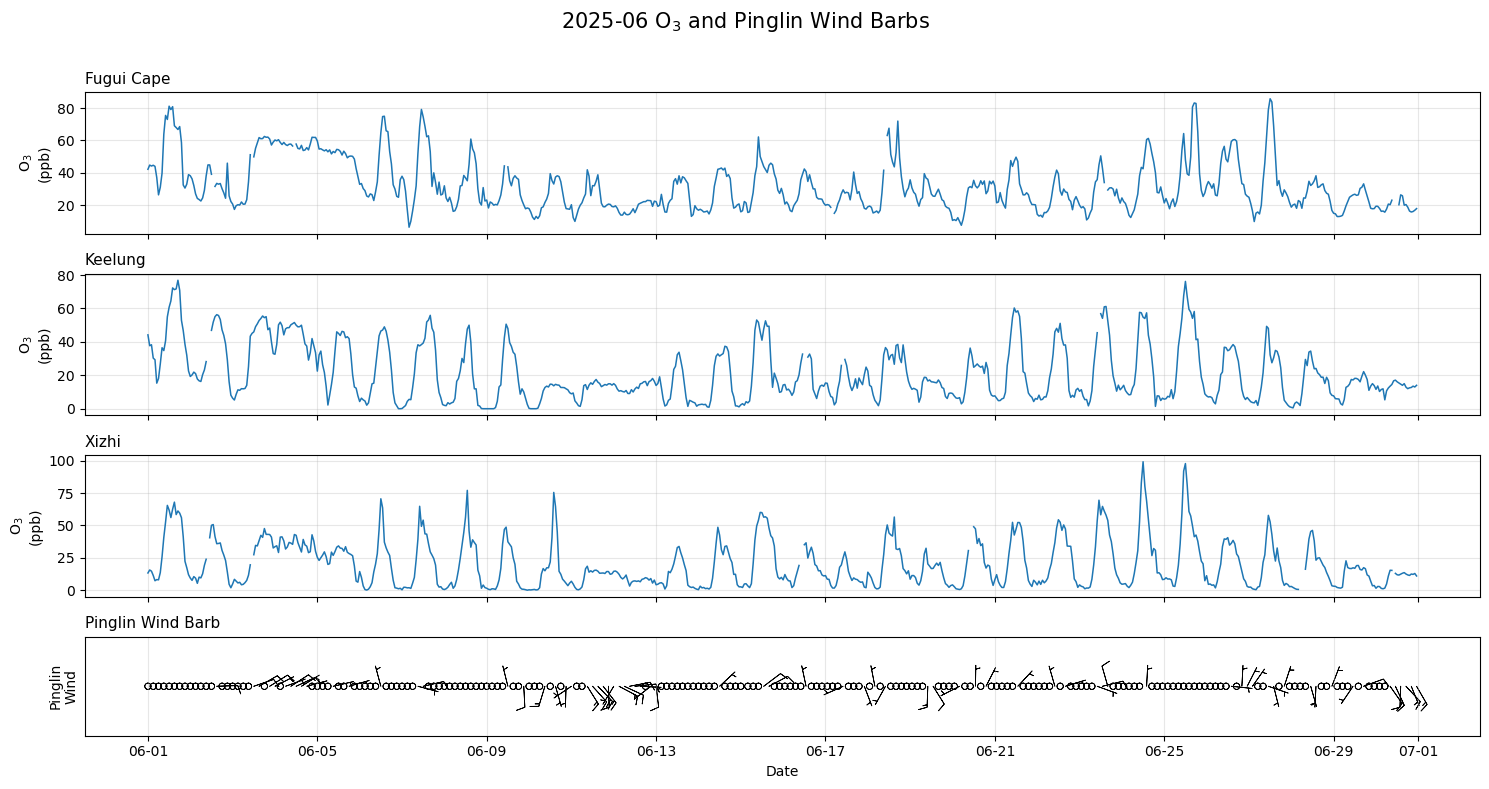

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_07.png


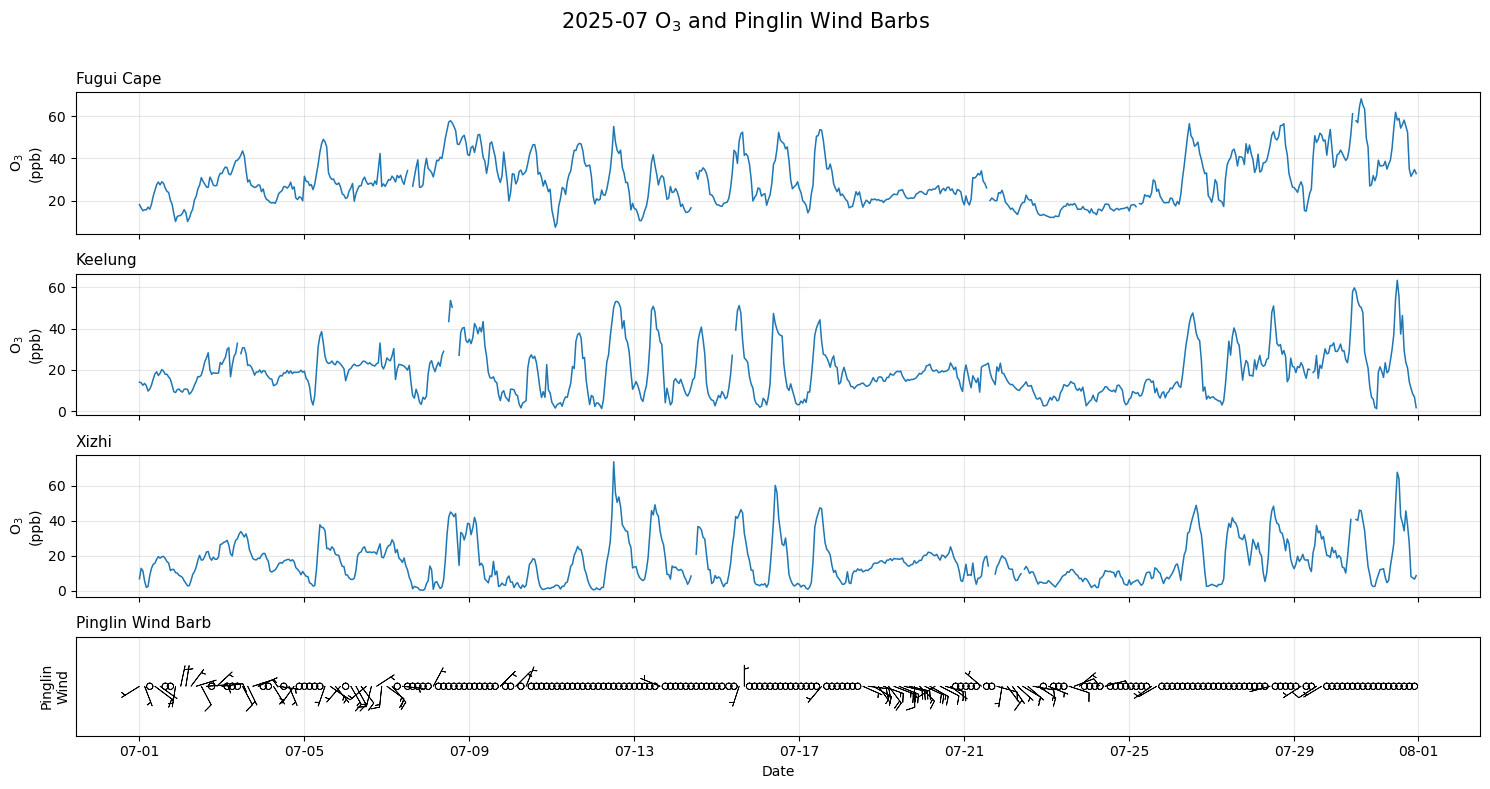

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_08.png


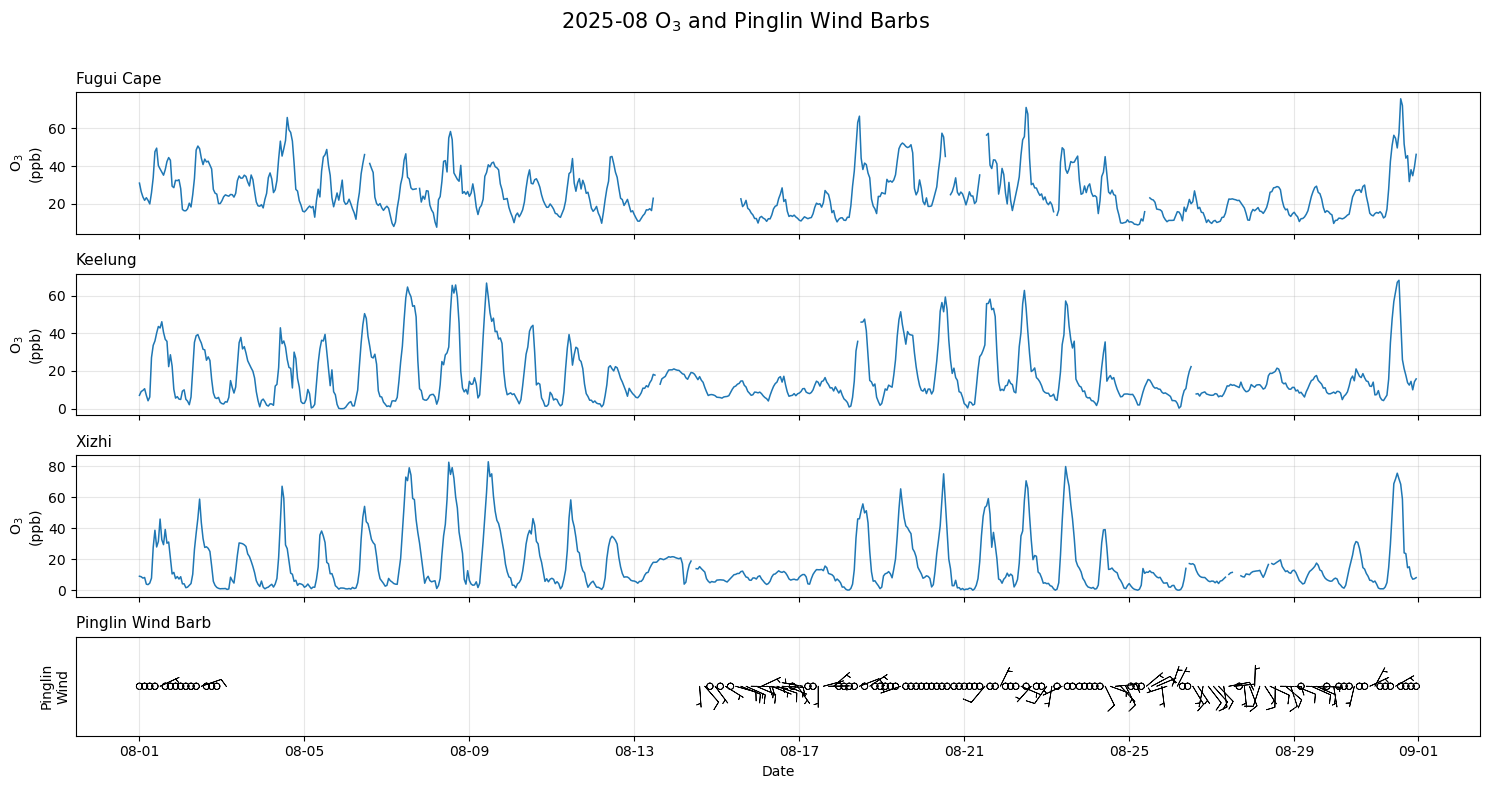

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_09.png


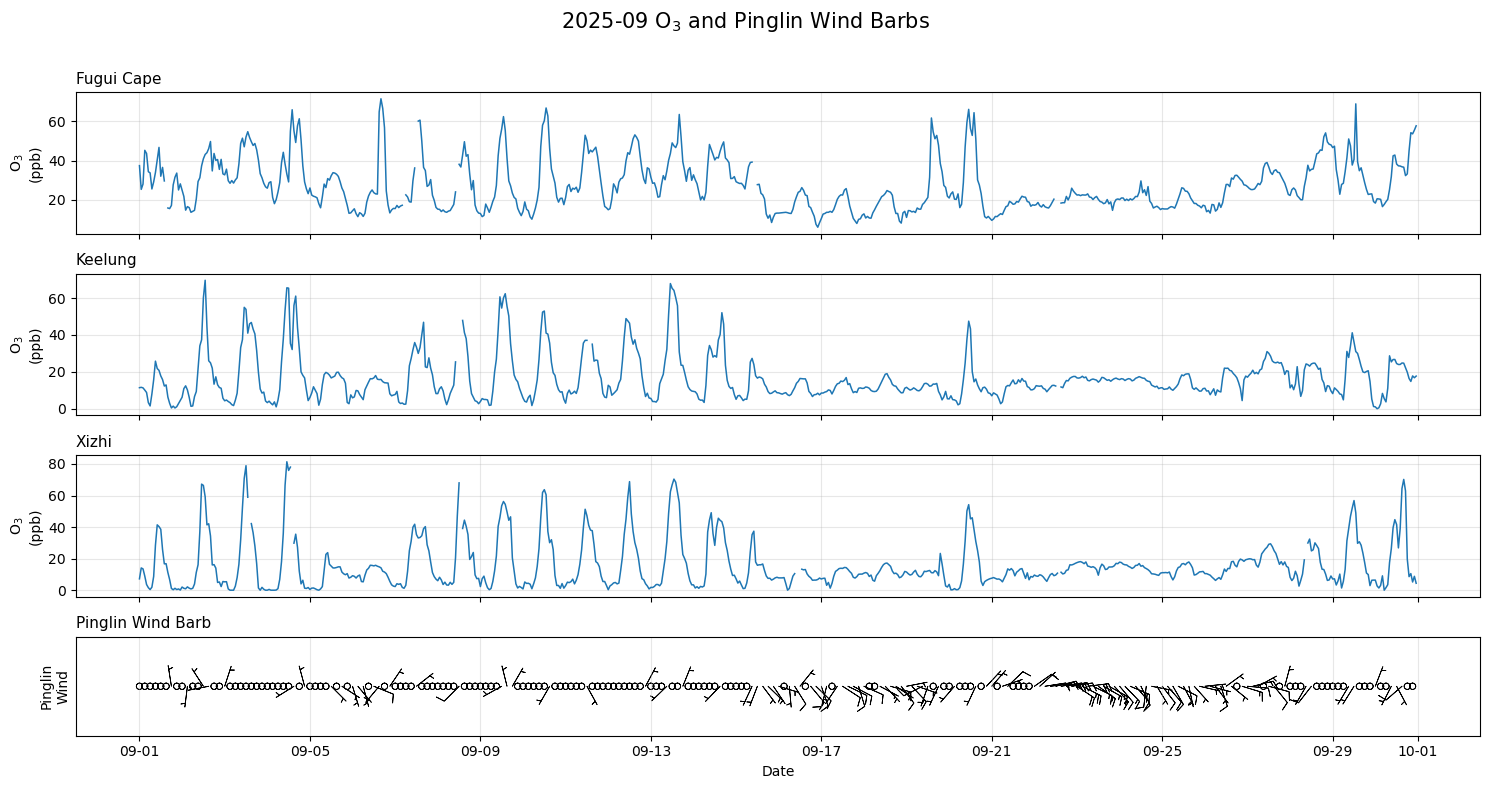

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_10.png


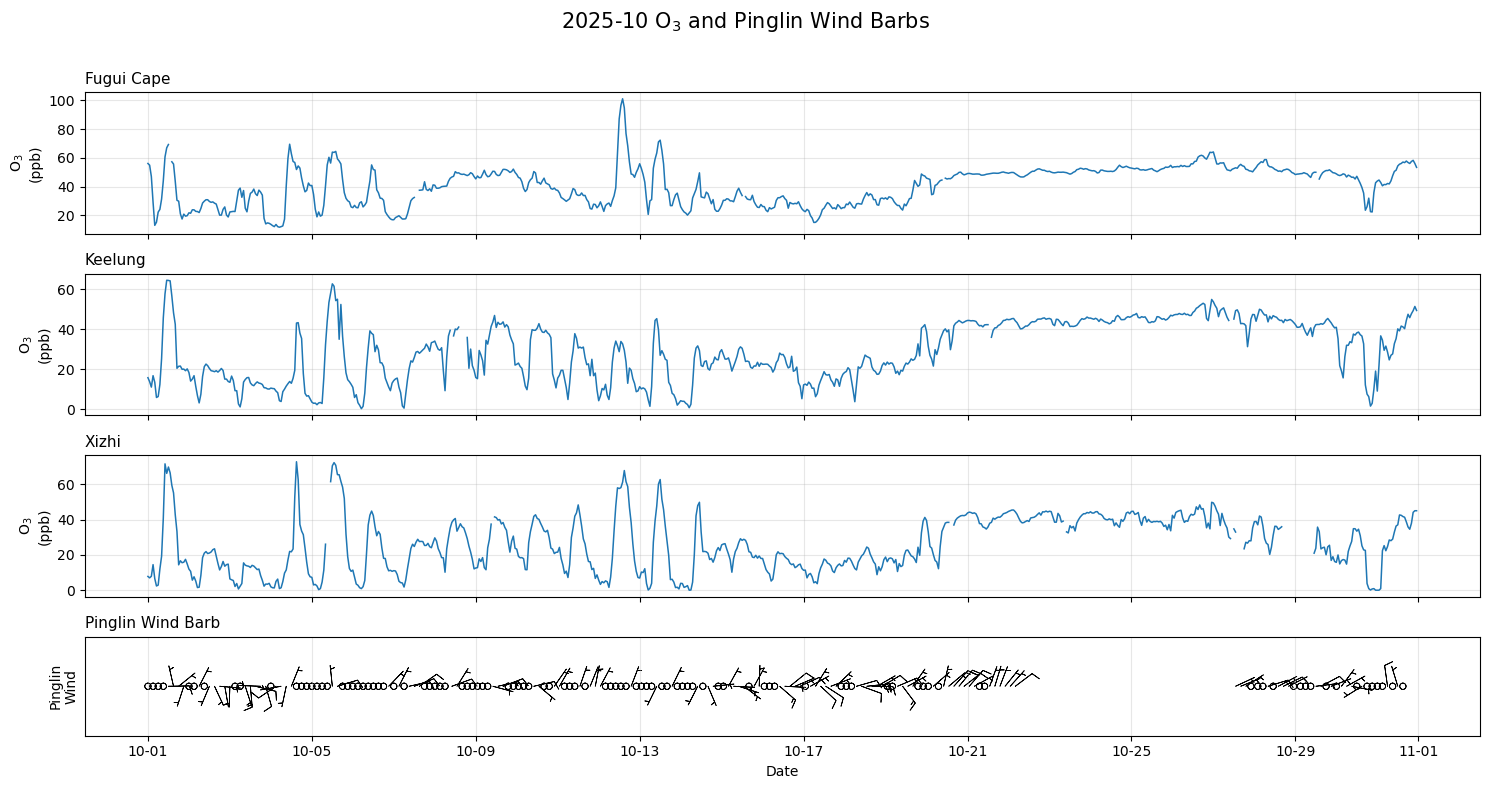

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_11.png


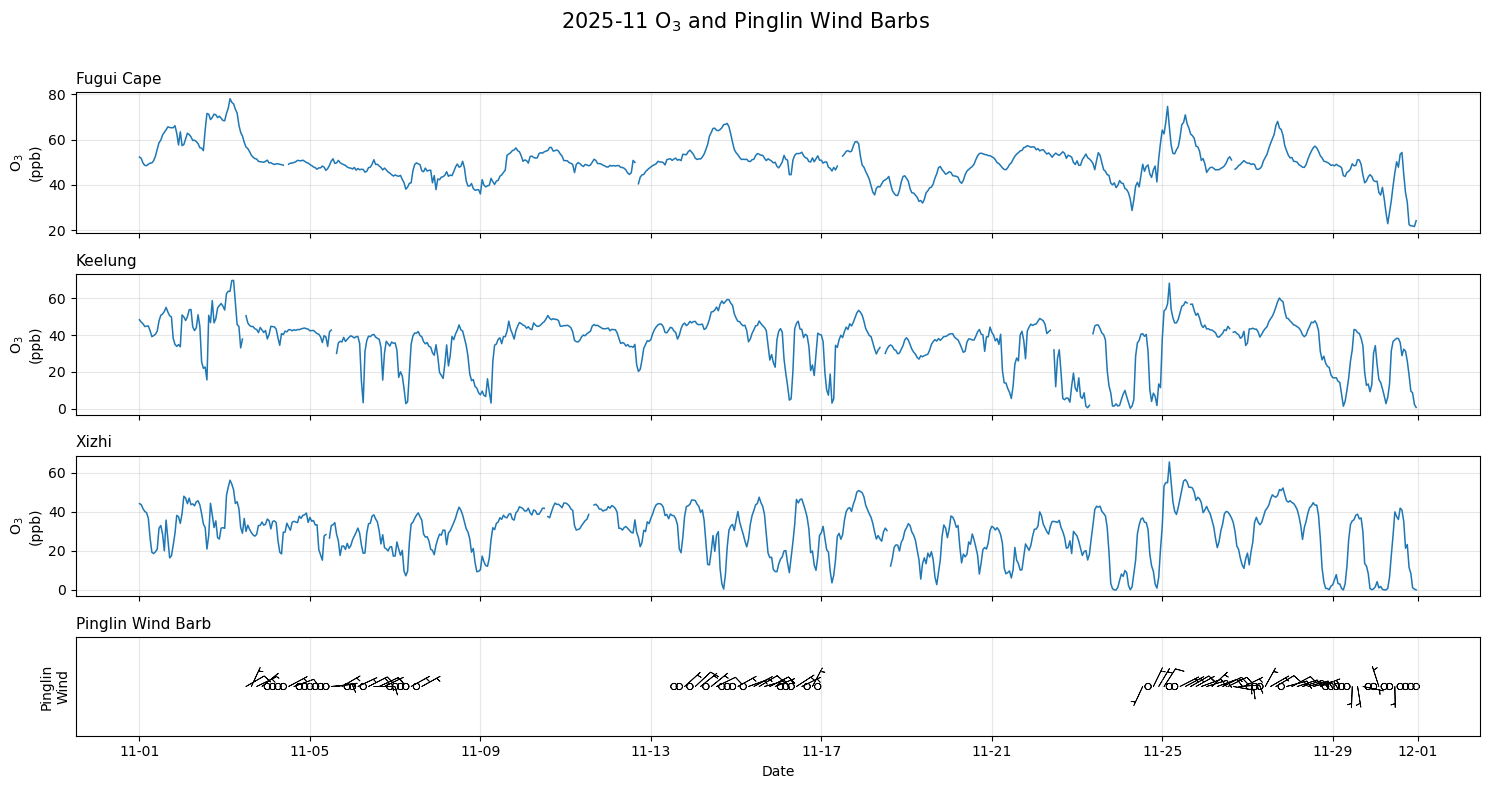

Saved: figures_o3_windbarb\O3_PinglinWindBarb_2025_12.png


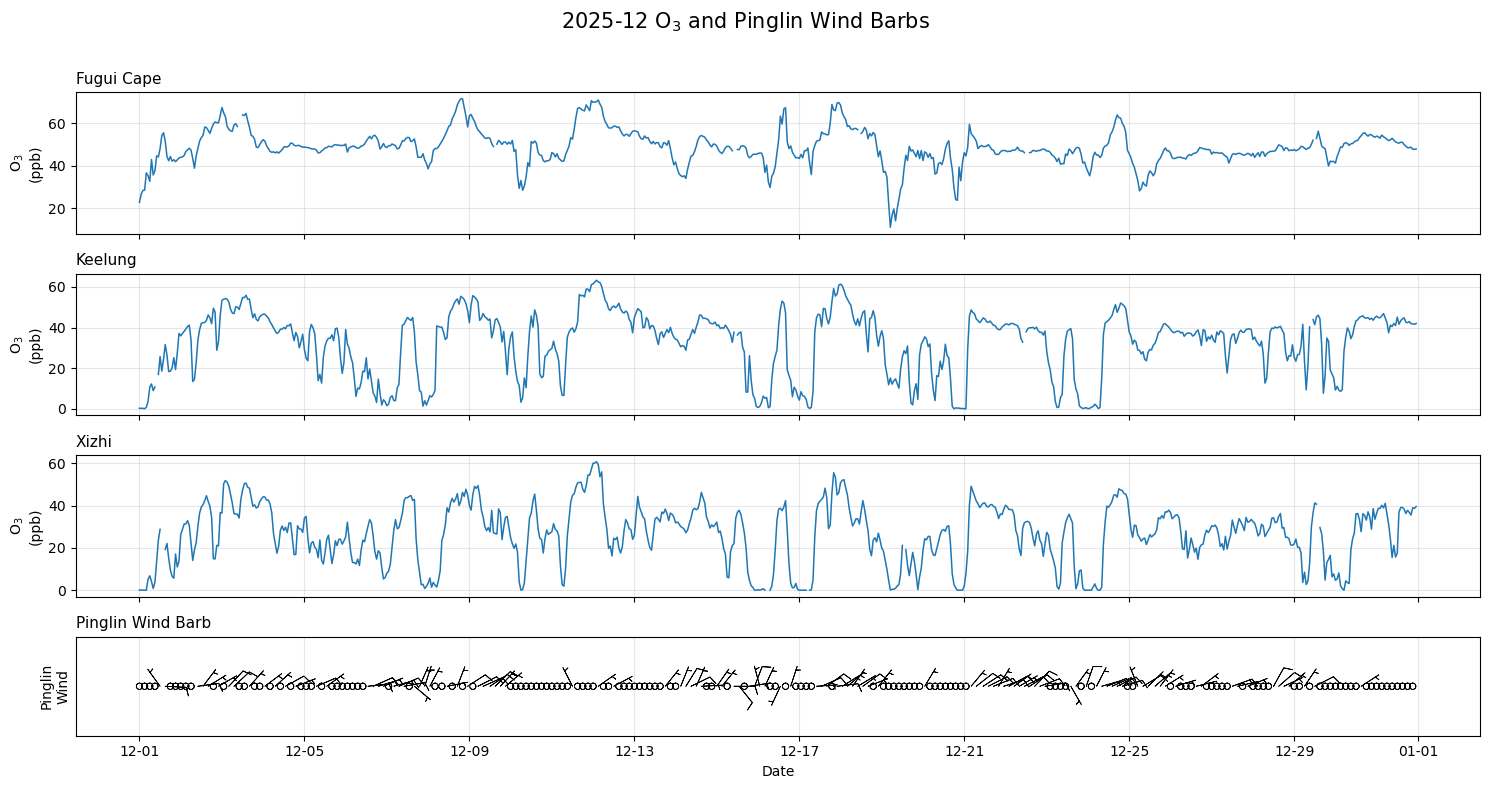

In [10]:
import numpy as np
import matplotlib.dates as mdates

def plot_monthly_o3_windbarb(month, save=True, out_dir="figures_o3_windbarb"):
    df_m = plot_df[plot_df["month"] == month].copy()
    wind_m = pinglin_wind[pinglin_wind["datetime"].dt.month == month].copy()

    Path(out_dir).mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(15, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1, 0.7]}
    )

    # =========================
    # A. O3 by station
    # =========================
    for i, station in enumerate(station_order):
        ax = axes[i]
        d = df_m[df_m["station_en"] == station]

        ax.plot(
            d["datetime"],
            d[o3_col],
            linewidth=1.1
        )

        ax.set_ylabel("O$_3$\n(ppb)")
        ax.set_title(station, loc="left", fontsize=11)
        ax.grid(alpha=0.3)

    # =========================
    # B. Pinglin wind barb
    # =========================
    ax_wind = axes[3]

    wind_m = wind_m.dropna(subset=["Pinglin_WS", "Pinglin_WD"]).copy()

    # 每 3 小時畫一支風標，避免太密
    wind_m = wind_m.iloc[::3, :]

    # 氣象風向：表示風從哪裡來
    # 轉成 u, v 分量
    wd_rad = np.deg2rad(wind_m["Pinglin_WD"])

    u = -wind_m["Pinglin_WS"] * np.sin(wd_rad)
    v = -wind_m["Pinglin_WS"] * np.cos(wd_rad)

    x = mdates.date2num(wind_m["datetime"])
    y = np.zeros(len(wind_m))

    ax_wind.barbs(
        x,
        y,
        u,
        v,
        length=5.5,
        linewidth=0.6,
        barb_increments=dict(half=1, full=2, flag=10)
    )

    ax_wind.set_ylim(-1, 1)
    ax_wind.set_yticks([])
    ax_wind.set_ylabel("Pinglin\nWind")
    ax_wind.set_title("Pinglin Wind Barb", loc="left", fontsize=11)
    ax_wind.grid(axis="x", alpha=0.3)

    # =========================
    # C. Time axis
    # =========================
    axes[-1].xaxis_date()
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    fig.suptitle(
        f"2025-{month:02d} O$_3$ and Pinglin Wind Barbs",
        fontsize=15
    )

    axes[-1].set_xlabel("Date")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save:
        save_path = Path(out_dir) / f"O3_PinglinWindBarb_2025_{month:02d}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
# =========================
# 3. 一次跑 12 個月
# =========================
for month in range(1, 13):
    plot_monthly_o3_windbarb(month, save=True)

C:\Users\user\AppData\Local\Temp\ipykernel_11992\3573553232.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["wd_bin", "ws_bin"])
C:\Users\user\AppData\Local\Temp\ipykernel_11992\3573553232.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["wd_bin", "ws_bin"])
C:\Users\user\AppData\Local\Temp\ipykernel_11992\3573553232.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["wd_bin", "ws

Saved: figures_pinglin_windrose\Pinglin_monthly_windrose_2025.png


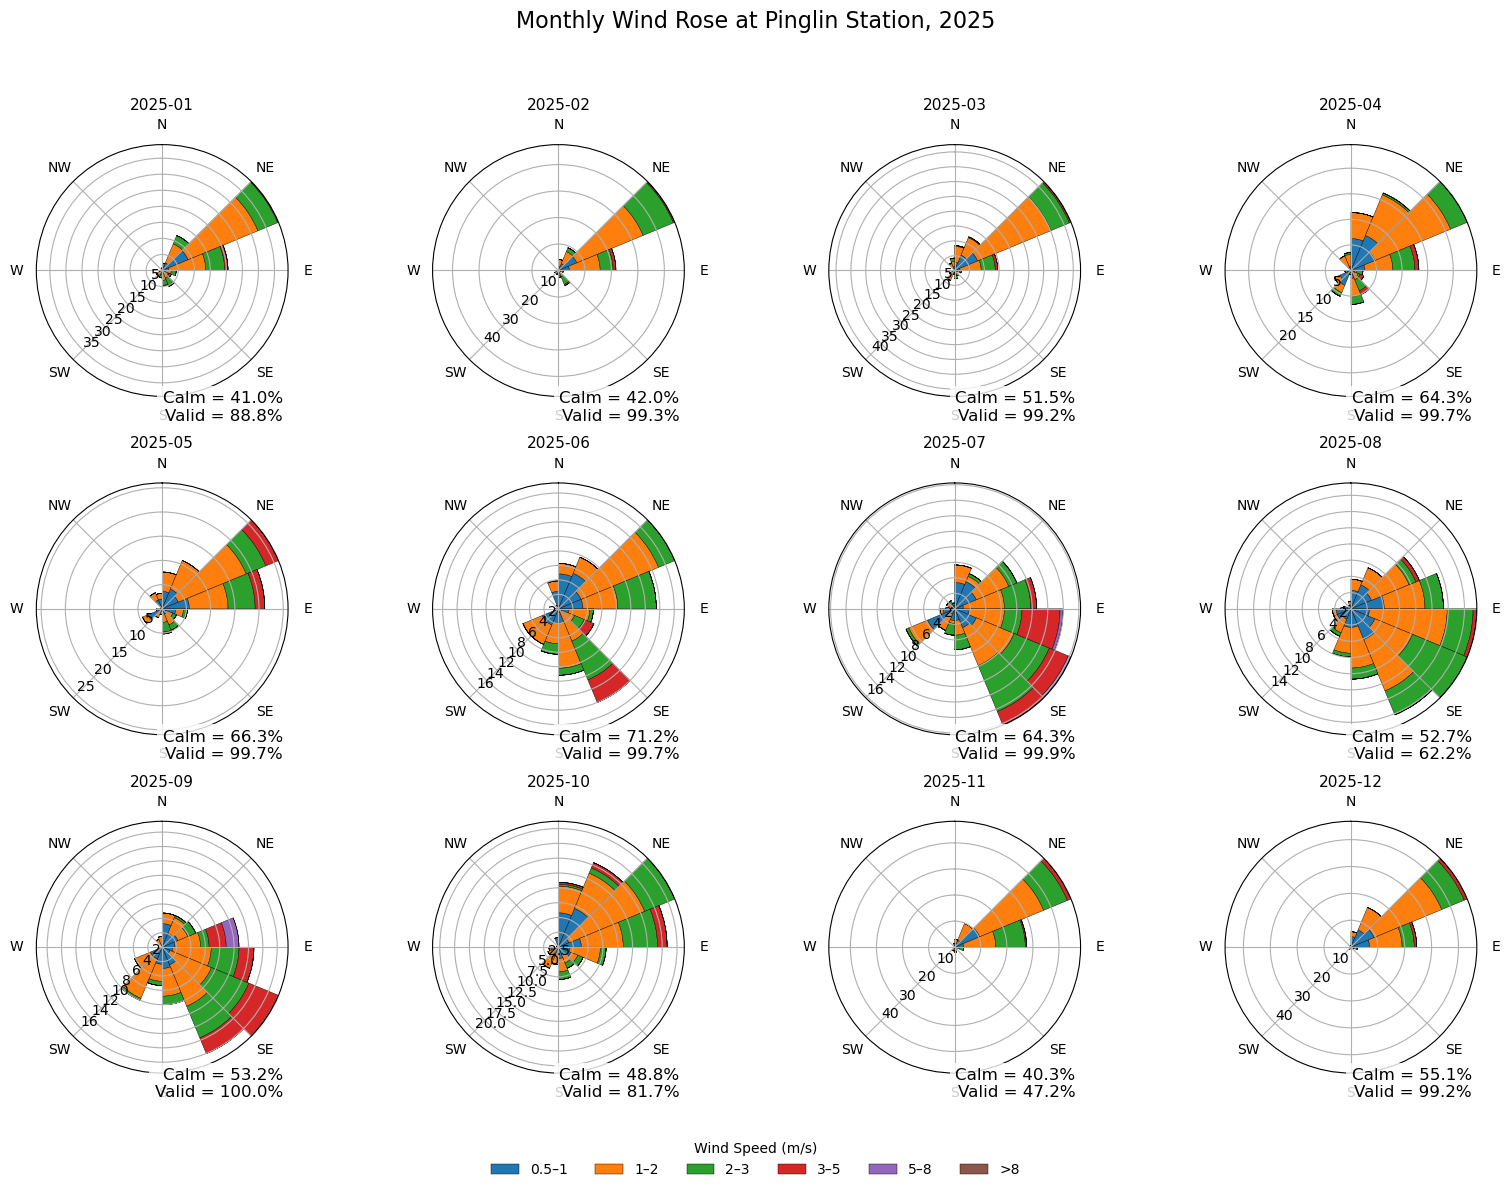

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. 風向分級設定
# =========================
direction_bins = np.arange(0, 361, 22.5)
direction_labels = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

speed_bins = [0.5, 1, 2, 3, 5, 8, np.inf]
speed_labels = ["0.5–1", "1–2", "2–3", "3–5", "5–8", ">8"]


# =========================
# 2. 單一月份風花圖函式
# =========================
def prepare_windrose_data(df, calm_threshold=0.5):
    wind = df.dropna(subset=["Pinglin_WS", "Pinglin_WD"]).copy()

    # 靜風不進入風花圖，只另外統計 Calm
    wind = wind[wind["Pinglin_WS"] > calm_threshold].copy()

    if len(wind) == 0:
        empty = pd.DataFrame(
            0,
            index=direction_labels,
            columns=speed_labels
        )
        return empty

    wind["wd_bin"] = pd.cut(
        wind["Pinglin_WD"] % 360,
        bins=direction_bins,
        labels=direction_labels,
        right=False,
        include_lowest=True
    )

    wind.loc[wind["Pinglin_WD"] >= 348.75, "wd_bin"] = "N"

    wind["ws_bin"] = pd.cut(
        wind["Pinglin_WS"],
        bins=speed_bins,
        labels=speed_labels,
        right=False
    )

    freq = (
        wind
        .groupby(["wd_bin", "ws_bin"])
        .size()
        .unstack(fill_value=0)
        .reindex(direction_labels)
        .reindex(columns=speed_labels, fill_value=0)
    )

    # 分母建議用「非靜風有效資料」
    freq_percent = freq / freq.values.sum() * 100

    return freq_percent

# =========================
# 3. 畫 12 個月風花圖
# =========================
def plot_monthly_windrose_12(pinglin_wind, save=True, out_dir="figures_pinglin_windrose"):
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    df = pinglin_wind.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["month"] = df["datetime"].dt.month

    theta = np.deg2rad(np.arange(0, 360, 22.5))
    width = np.deg2rad(22.5)

    fig, axes = plt.subplots(
        3, 4,
        figsize=(16, 12),
        subplot_kw={"projection": "polar"}
    )

    axes = axes.flatten()

    for month in range(1, 13):
        ax = axes[month - 1]
        df_m = df[df["month"] == month]

        # =====================
        # 統計 Calm 與 Valid
        # =====================
        total_obs = len(df_m)

        valid_mask = (
            df_m["Pinglin_WS"].notna() &
            df_m["Pinglin_WD"].notna()
        )

        valid_obs = valid_mask.sum()

        if total_obs > 0:
            valid_pct = valid_obs / total_obs * 100
        else:
            valid_pct = np.nan

        calm_obs = (
            df_m.loc[valid_mask, "Pinglin_WS"] <= 0.5
        ).sum()

        if valid_obs > 0:
            calm_pct = calm_obs / valid_obs * 100
        else:
            calm_pct = np.nan

        freq = prepare_windrose_data(df_m)

        bottom = np.zeros(len(direction_labels))

        for ws_label in speed_labels:
            values = freq[ws_label].values

            ax.bar(
                theta,
                values,
                width=width,
                bottom=bottom,
                align="edge",
                edgecolor="black",
                linewidth=0.3,
                label=ws_label
            )

            bottom += values

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        ax.set_title(f"2025-{month:02d}", fontsize=11)
        ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
        ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
        ax.set_rlabel_position(225)
        ax.text(
            0.98,
            0.02,
            f"Calm = {calm_pct:.1f}%\nValid = {valid_pct:.1f}%",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=12,
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none"
            )
      )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Wind Speed (m/s)",
        loc="lower center",
        ncol=len(speed_labels),
        frameon=False
    )

    fig.suptitle("Monthly Wind Rose at Pinglin Station, 2025", fontsize=16)

    plt.tight_layout(rect=[0, 0.06, 1, 0.95])

    if save:
        save_path = Path(out_dir) / "Pinglin_monthly_windrose_2025.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()


# =========================
# 4. 執行
# =========================
plot_monthly_windrose_12(
    pinglin_wind,
    save=True
)

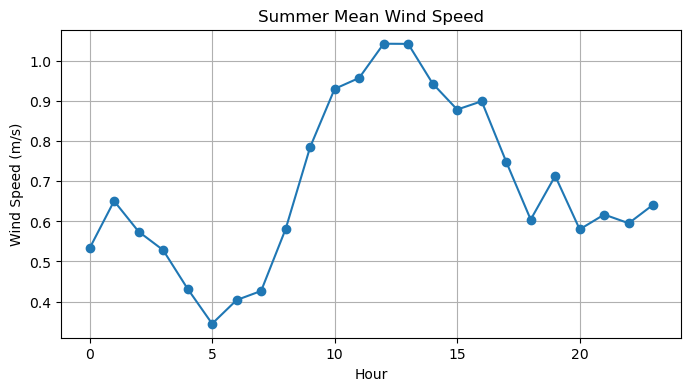

In [17]:
summer = pinglin_wind.copy()

summer = summer[
    summer["datetime"].dt.month.isin([6,7,8,9])
]

summer["hour"] = summer["datetime"].dt.hour

hourly_ws = (
    summer
    .groupby("hour")["Pinglin_WS"]
    .mean()
)

plt.figure(figsize=(8,4))
plt.plot(hourly_ws.index, hourly_ws.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (m/s)")
plt.title("Summer Mean Wind Speed")
plt.grid()
plt.show()

Total obs: 2928
Valid obs: 2644 (90.3%)
Calm obs: 1616 (61.1%)
Non-calm obs: 1028 (38.9%)


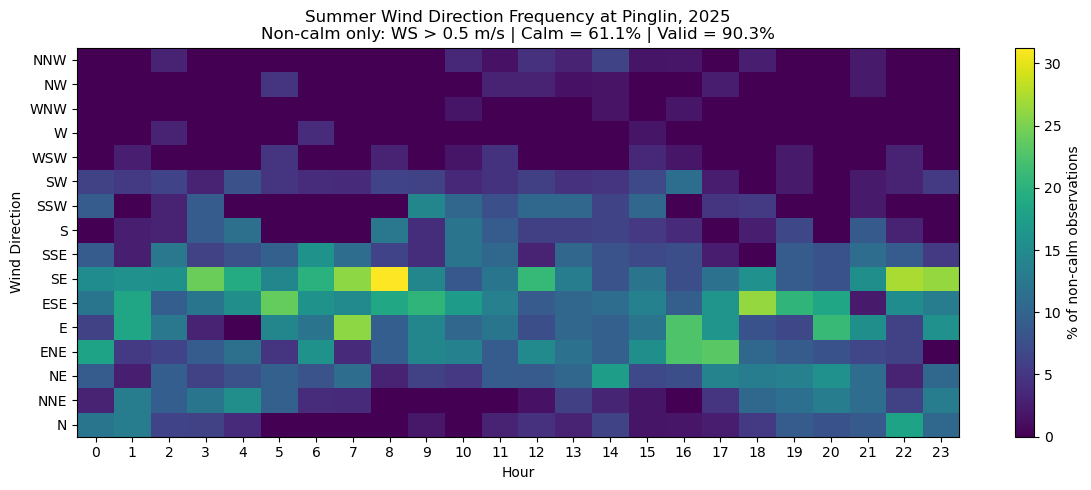

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 基本設定
# =========================
calm_threshold = 0.5

direction_bins = np.arange(0, 361, 22.5)

direction_labels = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]


# =========================
# 2. 建立夏季資料
# =========================
summer = pinglin_wind.copy()
summer["datetime"] = pd.to_datetime(summer["datetime"])
summer["month"] = summer["datetime"].dt.month
summer["hour"] = summer["datetime"].dt.hour

summer = summer[summer["month"].isin([6, 7, 8, 9])].copy()


# =========================
# 3. 統計 Calm / Valid
# =========================
valid_mask = (
    summer["Pinglin_WS"].notna() &
    summer["Pinglin_WD"].notna()
)

valid_obs = valid_mask.sum()
total_obs = len(summer)

calm_mask = valid_mask & (summer["Pinglin_WS"] <= calm_threshold)
noncalm_mask = valid_mask & (summer["Pinglin_WS"] > calm_threshold)

valid_pct = valid_obs / total_obs * 100
calm_pct = calm_mask.sum() / valid_obs * 100
noncalm_pct = noncalm_mask.sum() / valid_obs * 100

print(f"Total obs: {total_obs}")
print(f"Valid obs: {valid_obs} ({valid_pct:.1f}%)")
print(f"Calm obs: {calm_mask.sum()} ({calm_pct:.1f}%)")
print(f"Non-calm obs: {noncalm_mask.sum()} ({noncalm_pct:.1f}%)")


# =========================
# 4. 只保留非靜風資料做風向分析
# =========================
summer_nc = summer[noncalm_mask].copy()

summer_nc["direction"] = pd.cut(
    summer_nc["Pinglin_WD"] % 360,
    bins=direction_bins,
    labels=direction_labels,
    right=False,
    include_lowest=True
)

summer_nc.loc[
    summer_nc["Pinglin_WD"] >= 348.75,
    "direction"
] = "N"


# =========================
# 5. 夏季風向 × 小時熱圖
# =========================
freq = (
    summer_nc
    .groupby(["hour", "direction"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=direction_labels, fill_value=0)
)

freq_pct = freq.div(freq.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))

plt.imshow(
    freq_pct.T,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=np.nanmax(freq_pct.values)
)

plt.colorbar(label="% of non-calm observations")

plt.yticks(
    range(len(direction_labels)),
    direction_labels
)

plt.xticks(
    range(24),
    range(24)
)

plt.xlabel("Hour")
plt.ylabel("Wind Direction")
plt.title(
    f"Summer Wind Direction Frequency at Pinglin, 2025\n"
    f"Non-calm only: WS > {calm_threshold} m/s | Calm = {calm_pct:.1f}% | Valid = {valid_pct:.1f}%"
)
plt.savefig("Summer Wind Direction Frequency at Pinglin.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [25]:
summer_nc.groupby("direction")["Pinglin_WS"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_11992\832730128.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summer_nc.groupby("direction")["Pinglin_WS"].mean()


direction
N      0.900000
NNE    0.940351
NE     1.332292
ENE    1.935043
E      1.958871
ESE    2.131293
SE     1.896815
SSE    1.349367
S      1.292453
SSW    1.190741
SW     1.070833
WSW    0.808333
W      0.766667
WNW    1.000000
NW     0.833333
NNW    1.147059
Name: Pinglin_WS, dtype: float64

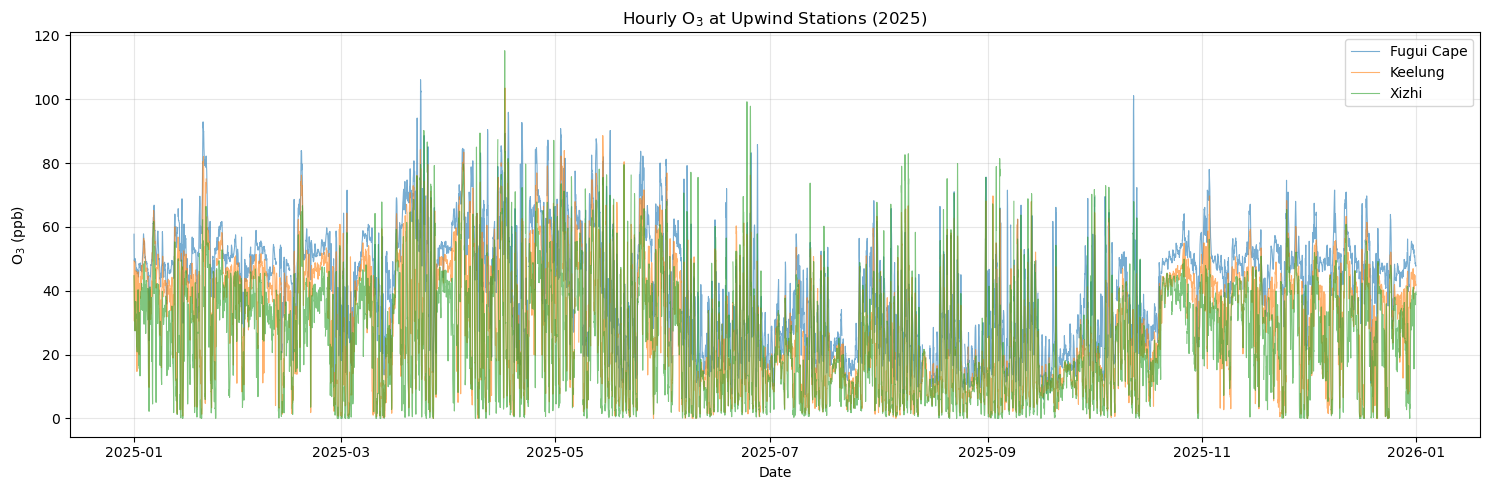

In [61]:
#o3年時序圖
import matplotlib.pyplot as plt
import pandas as pd

# 臭氧欄位名稱
o3_col = "O3"

# 英文站名
station_map = {
    "富貴角": "Fugui Cape",
    "基隆": "Keelung",
    "汐止": "Xizhi"
}

plot_df = data.copy()
plot_df["datetime"] = pd.to_datetime(plot_df["datetime"])
plot_df["station_en"] = plot_df["station"].map(station_map)

# =========================
# 全年小時資料
# =========================
plt.figure(figsize=(15,5))

for st in ["Fugui Cape", "Keelung", "Xizhi"]:

    tmp = plot_df[
        plot_df["station_en"] == st
    ]

    plt.plot(
        tmp["datetime"],
        tmp[o3_col],
        linewidth=0.8,
        alpha=0.6,
        label=st
    )

plt.ylabel("O$_3$ (ppb)")
plt.xlabel("Date")
plt.title("Hourly O$_3$ at Upwind Stations (2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Hourly O$_3$ at Upwind Stations (2025).png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

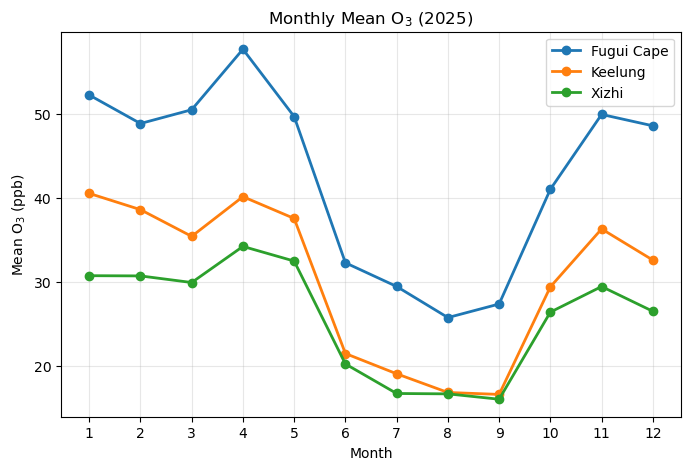

In [62]:
#o3月平均
monthly_o3 = (
    plot_df
    .groupby([
        plot_df["datetime"].dt.month.rename("month"),
        "station_en"
    ])[o3_col]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))


for st in ["Fugui Cape", "Keelung", "Xizhi"]:

    tmp = monthly_o3[
        monthly_o3["station_en"] == st
    ]

    plt.plot(
        tmp["month"],
        tmp[o3_col],
        marker="o",
        linewidth=2,
        label=st
    )

plt.xlabel("Month")
plt.ylabel("Mean O$_3$ (ppb)")
plt.title("Monthly Mean O$_3$ (2025)")
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Monthly Mean O$_3$ (2025).png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
#按照風向來分類臭氧
import numpy as np
import pandas as pd

plot_df = data.copy()

# 排除靜風
plot_df = plot_df[
    (plot_df["Pinglin_WS"] > 0.5)
    & (plot_df["Pinglin_WD"].notna())
     &plot_df["datetime"].dt.month.isin([11,12,1,2,3])
].copy()

# 八方位
bins = [0,45,90,135,180,225,270,315,360]

labels = [
    "N",
    "NE",
    "E",
    "SE",
    "S",
    "SW",
    "W",
    "NW"
]

plot_df["wind_sector"] = pd.cut(
    plot_df["Pinglin_WD"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

o3_sector = (
    plot_df
    .groupby(
        ["wind_sector","station_en"],
        observed=False
    )["O3"]
    .mean()
    .reset_index()
)

print(o3_sector)

   wind_sector  station_en         O3
0            N  Fugui Cape  51.933721
1            N     Keelung  32.884436
2            N       Xizhi  25.790698
3           NE  Fugui Cape  52.918063
4           NE     Keelung  43.396200
5           NE       Xizhi  35.313889
6            E  Fugui Cape  54.536667
7            E     Keelung  45.056716
8            E       Xizhi  39.007463
9           SE  Fugui Cape  52.037895
10          SE     Keelung  43.780412
11          SE       Xizhi  37.659596
12           S  Fugui Cape  51.413462
13           S     Keelung  42.489286
14           S       Xizhi  37.050000
15          SW  Fugui Cape  45.276667
16          SW     Keelung  33.276667
17          SW       Xizhi  27.554839
18           W  Fugui Cape  59.000000
19           W     Keelung  53.700000
20           W       Xizhi  52.300000
21          NW  Fugui Cape  47.312963
22          NW     Keelung  36.906000
23          NW       Xizhi  36.385185


In [35]:
station_map = {
    "富貴角": "Fugui Cape",
    "基隆": "Keelung",
    "汐止": "Xizhi"
}

data["station_en"] = data["station"].map(station_map)

print(data[["station","station_en"]].drop_duplicates())

      station  station_en
0          汐止       Xizhi
8739      富貴角  Fugui Cape
17447      基隆     Keelung


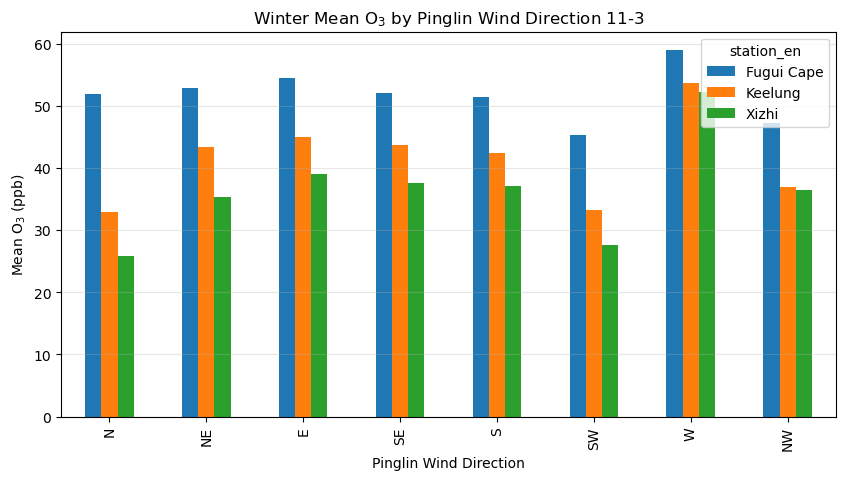

In [65]:
import matplotlib.pyplot as plt

pivot = o3_sector.pivot(
    index="wind_sector",
    columns="station_en",
    values="O3"
)

pivot = pivot.loc[
    ["N","NE","E","SE","S","SW","W","NW"]
]

pivot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Mean O$_3$ (ppb)")
plt.xlabel("Pinglin Wind Direction")
plt.title("Winter Mean O$_3$ by Pinglin Wind Direction 11-3")

plt.grid(axis="y", alpha=0.3)
plt.savefig("Winter Mean O$_3$ by Pinglin Wind Direction 11-3.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
winter_raw = plot_df[
    plot_df["datetime"].dt.month.isin([11,12,1,2,3])
].copy()

print(len(winter_raw))

print(
    winter_raw.groupby(
        "wind_sector",
        observed=False
    ).size()
)


5002
wind_sector
N      780
NE    3282
E      207
SE     300
S      168
SW      93
W        3
NW     160
dtype: int64


In [54]:
summer_raw = plot_df[
    plot_df["datetime"].dt.month.isin([6,7,8,9])
].copy()

print(
    summer_raw.groupby(
        "wind_sector",
        observed=False
    ).size()
)

wind_sector
N     303
NE    639
E     805
SE    696
S     320
SW    180
W      18
NW     99
dtype: int64


In [58]:
# 坪林風場
pinglin_wind.to_csv(
    r"C:\臺大雲端\lab\Pinglin_O3_Project\processed\pinglin_wind_2025.csv",
    index=False,
    encoding="utf-8-sig"
)


# 最終分析資料
data.to_csv(
    r"C:\臺大雲端\lab\Pinglin_O3_Project\processed\merged_o3_wind.csv",
    index=False,
    encoding="utf-8-sig"
)
